In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\Acer\\Documents\\GitHub\\energy-demand-forecast\\data\\demand_2025_hourly.csv")  # ajusta el nom si l'has guardat diferent
df['datetime'] = pd.to_datetime(df['datetime'])  # comprova el nom exacte de la columna de temps
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)
df.index = pd.to_datetime(df.index, utc=True).tz_convert('Europe/Madrid')
df.head()

C:\Users\Acer\AppData\Local\Temp\ipykernel_19968\1948255251.py:5: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['datetime'] = pd.to_datetime(df['datetime'])  # comprova el nom exacte de la columna de temps


,value,datetime_utc,tz_time,geo_id,geo_name
datetime,,,,,
2025-01-01 00:00:00+01:00,275088.0,2024-12-31T23:00:00Z,2024-12-31T23:00:00.000Z,8741,Península
2025-01-01 01:00:00+01:00,266231.0,2025-01-01T00:00:00Z,2025-01-01T00:00:00.000Z,8741,Península
2025-01-01 02:00:00+01:00,251434.0,2025-01-01T01:00:00Z,2025-01-01T01:00:00.000Z,8741,Península
2025-01-01 03:00:00+01:00,237297.0,2025-01-01T02:00:00Z,2025-01-01T02:00:00.000Z,8741,Península
2025-01-01 04:00:00+01:00,227683.0,2025-01-01T03:00:00Z,2025-01-01T03:00:00.000Z,8741,Península


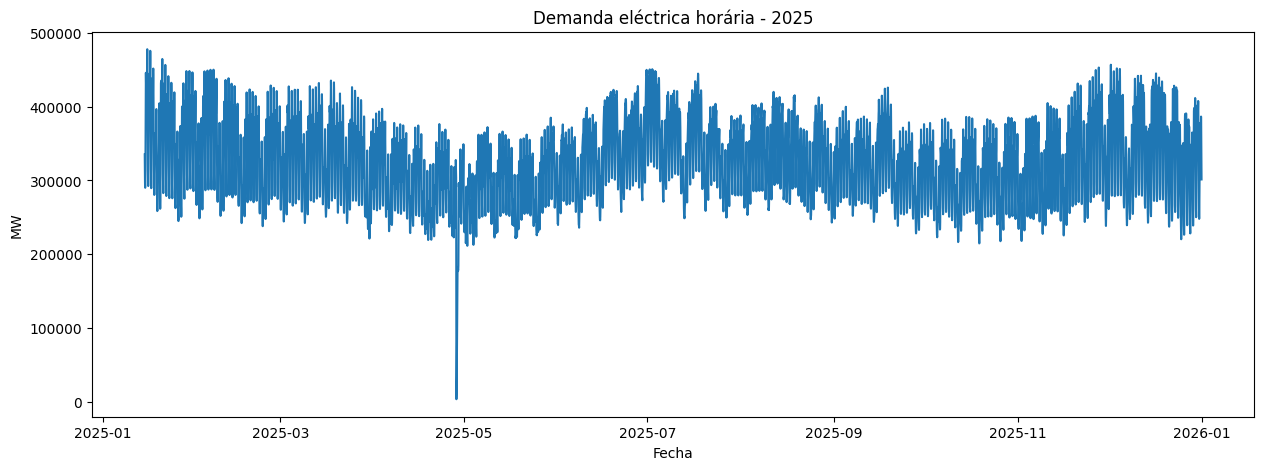

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['value'])
plt.title("Demanda eléctrica horária - 2025")
plt.xlabel("Fecha")
plt.ylabel("MW")
plt.savefig('../outputs/demand_yearly.png', dpi=150)
plt.show()

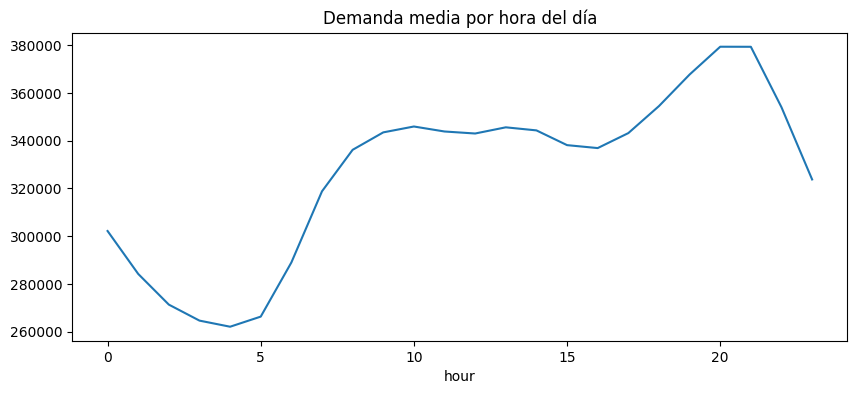

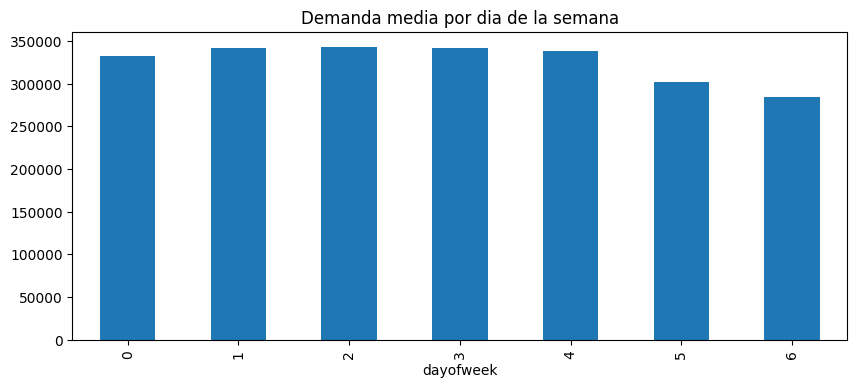

In [16]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek  # 0=dilluns, 6=diumenge
df['month'] = df.index.month

# Patró diari mitjà
df.groupby('hour')['value'].mean().plot(kind='line', figsize=(10,4), title='Demanda media por hora del día')
plt.show()

# Patró setmanal
df.groupby('dayofweek')['value'].mean().plot(kind='bar', figsize=(10,4), title='Demanda media por dia de la semana')
plt.show()

Feature engineering

In [13]:
df['dayofyear'] = df.index.dayofyear
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

# Variables cícliques (per capturar que hora 23 i hora 0 són "properes")
import numpy as np
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Lags (valor de fa 24h i fa 1 setmana, molt predictius per demanda)
df['lag_24h'] = df['value'].shift(24)
df['lag_168h'] = df['value'].shift(168)  # 24*7
# Marcar el dia de l'apagada com a esdeveniment atípic
blackout_start = "2025-04-28"
blackout_end = "2025-04-28"
df['is_blackout'] = ((df.index.date >= pd.to_datetime(blackout_start).date()) & 
                      (df.index.date <= pd.to_datetime(blackout_end).date())).astype(int)

df.dropna(inplace=True)
df.head()

,value,datetime_utc,tz_time,geo_id,geo_name,hour,dayofweek,month,dayofyear,is_weekend,hour_sin,hour_cos,month_sin,month_cos,lag_24h,lag_168h,is_blackout
datetime,,,,,,,,,,,,,,,,,
2025-01-15 00:00:00+01:00,335243.0,2025-01-14T23:00:00Z,2025-01-14T23:00:00.000Z,8741,Península,0,2,1,15,0,0.000000,1.000000,0.5,0.866025,324492.0,315876.0,0
2025-01-15 01:00:00+01:00,312619.0,2025-01-15T00:00:00Z,2025-01-15T00:00:00.000Z,8741,Península,1,2,1,15,0,0.258819,0.965926,0.5,0.866025,304851.0,290801.0,0
2025-01-15 02:00:00+01:00,297054.0,2025-01-15T01:00:00Z,2025-01-15T01:00:00.000Z,8741,Península,2,2,1,15,0,0.500000,0.866025,0.5,0.866025,291730.0,275867.0,0
2025-01-15 03:00:00+01:00,290274.0,2025-01-15T02:00:00Z,2025-01-15T02:00:00.000Z,8741,Península,3,2,1,15,0,0.707107,0.707107,0.5,0.866025,285897.0,269501.0,0
2025-01-15 04:00:00+01:00,290011.0,2025-01-15T03:00:00Z,2025-01-15T03:00:00.000Z,8741,Península,4,2,1,15,0,0.866025,0.500000,0.5,0.866025,284080.0,269468.0,0
